In [1]:
import matplotlib as mpl
%matplotlib inline
# Set the font to Times New Roman or a similar serif font
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
# Adjust the text sizes
mpl.rcParams['axes.labelsize'] = 10  # For X and Y axis labels
mpl.rcParams['axes.titlesize'] = 10  # For the plot title
mpl.rcParams['legend.fontsize'] = 10 # For the legend

import sys
sys.path.append('../')
from utils_models import *

In [2]:
tune_tmon = scqubits.TunableTransmon(
    EJmax=50.0,
    EC=0.5,
    d=0.01,
    flux=0.0,
    ng=0.0,
    ncut=30
    )

tune_tmon.eigenvals()

array([-43.05626926, -29.4337015 , -16.35888085,  -3.87246819,
         7.9726168 ,  19.10737192])

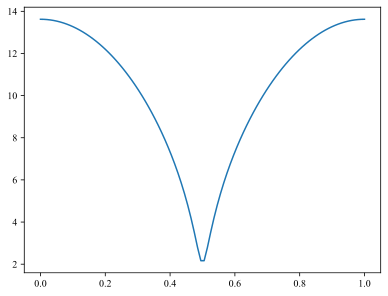

In [9]:
flux = np.linspace(0,1,100)
ge = []
for f in flux:
    tune_tmon = scqubits.TunableTransmon(
        EJmax=50.0,
        EC=0.5,
        d=0.01,
        flux=f,
        ng=0.0,
        ncut=30
        )
    evals = tune_tmon.eigenvals()
    ge.append(evals[1]-evals[0])

plt.plot(flux,ge)

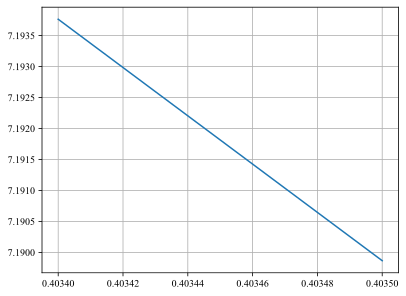

In [16]:
flux = np.linspace(0.4034,0.4035,100)
ge = []
for f in flux:
    tune_tmon = scqubits.TunableTransmon(
        EJmax=50.0,
        EC=0.5,
        d=0.01,
        flux=f,
        ng=0.0,
        ncut=30
        )
    evals = tune_tmon.eigenvals()
    ge.append(evals[1]-evals[0])

plt.plot(flux,ge)
plt.grid()

In [3]:
fluxonium = scqubits.Fluxonium(EJ=2.7,
                         EC=0.6,
                         EL=0.13,
                         flux=0,cutoff=110,
                         truncated_dim=20)
tune_tmon = scqubits.TunableTransmon(
        EJmax=50.0,
        EC=0.5,
        d=0.01,
        flux=0.403471,
        ng=0.0,
        ncut=30
        )

hilbertspace = scqubits.HilbertSpace([fluxonium, tune_tmon])
hilbertspace.add_interaction(
    g_strength=0.2,
    op1=fluxonium.n_operator,
    op2=tune_tmon.n_operator,
    add_hc=False
)
hilbertspace.generate_lookup()

chi0 = transition_frequency(hilbertspace,hilbertspace.dressed_index((0,0)),hilbertspace.dressed_index((0,1))) - (tune_tmon.eigenvals()[1]-tune_tmon.eigenvals()[0])
chi1 = transition_frequency(hilbertspace,hilbertspace.dressed_index((1,0)),hilbertspace.dressed_index((1,1))) - (tune_tmon.eigenvals()[1]-tune_tmon.eigenvals()[0])
chi2 = transition_frequency(hilbertspace,hilbertspace.dressed_index((2,0)),hilbertspace.dressed_index((2,1))) - (tune_tmon.eigenvals()[1]-tune_tmon.eigenvals()[0])
shifts = [
    chi0,
    chi1,
    chi2
]
shifts

[-0.0015560799890614874, 0.001650251796290192, 0.0016740709318989744]

In [7]:
tune_tmon.eigenvals()[1]-tune_tmon.eigenvals()[0]

7.190996762003433

In [6]:
op = hilbertspace.op_in_dressed_eigenbasis(tune_tmon.n_operator)

for i in range(3):
    print(abs(op[hilbertspace.dressed_index((i,0)),hilbertspace.dressed_index((i,1))]))

0.9167748249647126
0.9456045581294206
0.9469554924179768


In [8]:
amp = 0.004
t_tot = np.pi/amp/0.9167748249647126
t_tot

856.6969140188583

In [5]:
EJ_values = np.linspace(2, 3.5, 150)
Er_values = np.linspace(6.75, 7.6, 150)
EC = 0.6
EL = 0.13

returned_tuple = get_EJ_Er_sweep_data(EJ_values, 
                                    Er_values,
                                    EC,
                                    EL,
                                    computational_state = [1,2],
                                    leakage_state = 0,
                                    )

with open('pickles/EJEr_sweep_12.pkl', 'wb') as file:
    pickle.dump(returned_tuple, file)


In [2]:
EJ_values = np.linspace(2, 3.5, 150)
Er_values = np.linspace(6.75, 7.6, 150)
EC = 0.6
EL = 0.13

# returned_tuple = get_EJ_Er_sweep_data_diagonalization(EJ_values, 
#                                     Er_values,
#                                     EC,
#                                     EL,
#                                     g = 0.13,
#                                     computational_state = [1,2],
#                                     leakage_state = 0,
#                                     )

# with open('../pickles/EJEr_sweep_12_diagonalization.pkl', 'wb') as file:
#     pickle.dump(returned_tuple, file)
